# Analyzing Naming Trends Using Python
## By: Ayush Trivedi

### Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from zipfile import ZipFile

### Extract ZIP File

In [2]:
zip_path = r"C:\Users\ayush\Downloads\Python Projects\names.zip" 

### Initializing an empty DataFrame to store all data

In [3]:
all_data = []

with ZipFile(zip_path, "r") as z:
    # Looping through each file in the ZIP archive
    for file_name in z.namelist():
        if file_name.startswith("yob") and file_name.endswith(".txt"):  # Process only yobYYYY.txt files
            year = int(file_name[3:7])  # Extracting year from file name
            with z.open(file_name) as file:
                # Read CSV data (no header, columns: Name, Gender, Count)
                df = pd.read_csv(file, names=["Name", "Gender", "Count"])
                df["Year"] = year  # Adding year column
                all_data.append(df)

### Combining all years into a single DataFrame

In [4]:
baby_names = pd.concat(all_data)

### Visualizing Number of Male and Female Births per Year

In [5]:
gender_trends = baby_names.groupby(["Year", "Gender"])["Count"].sum().unstack()

### Plot trends

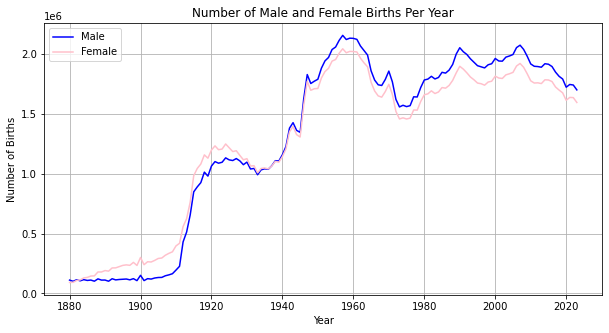

In [6]:
# Plot trends
plt.figure(figsize=(10, 5))

# Extract the "M" and "F" columns for plotting
male_births = gender_trends["M"].values  # Extract Male births as a numpy array
female_births = gender_trends["F"].values  # Extract Female births as a numpy array

# Plot the data
plt.plot(gender_trends.index, male_births, label="Male", color="blue")
plt.plot(gender_trends.index, female_births, label="Female", color="pink")

plt.xlabel("Year")
plt.ylabel("Number of Births")
plt.title("Number of Male and Female Births Per Year")
plt.legend()
plt.grid(True)
plt.show()


### Finding the Most Popular Baby Names

In [7]:
top_names = baby_names.groupby("Name")["Count"].sum().sort_values(ascending=False).head(100)

### Displaying the top 10 most popular names

In [8]:
print("Top 10 Most Popular Baby Names:")
print(top_names.head(10))

Top 10 Most Popular Baby Names:
Name
James      5250328
John       5187975
Robert     4862085
Michael    4431942
William    4194193
Mary       4152044
David      3675136
Joseph     2665333
Richard    2583933
Charles    2435467
Name: Count, dtype: int64
